In [ ]:
import os
import pickle
import random
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sbi import analysis as analysis

from tabpfn_sbi.tasks.allen_task import AllenTask
from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS

work_dir = os.environ.get("WORK")
print(work_dir)


def set_seed(seed: int):
    """This methods just sets the seed."""
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


run_result_dir = os.path.join(work_dir, "tabpfn_sbi/results/allen")
csv_path = os.path.join(run_result_dir, "summary.csv")

/mnt/lustre/work/macke/mwe824


Processing observation 1
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.01s
Processing observation 2
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.03s
Processing observation 3
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.01s
Processing observation 4
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.02s
Processing observation 5
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.01s
Processing observation 6
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.02s
Processing observation 7
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.01s
Processing observation 8
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sampling took 0.02s
Processing observation 9
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>
Sam

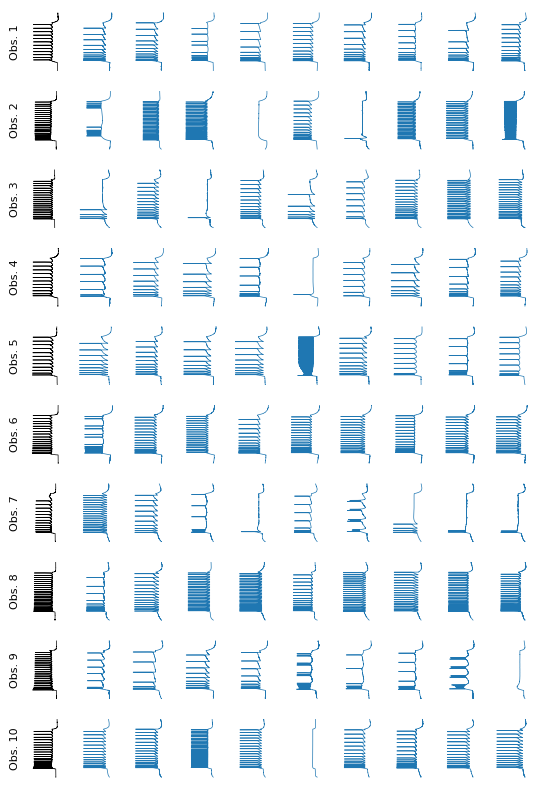

In [ ]:
df = pd.read_csv(csv_path)

method_name = "tsnpe"
task_name = "allen"
num_simulations = 10000
seed = 4  # run seed
obs_type = (
    "real"  # NOTE: IMPORTANT to set this correctly in accordance with the result dir
)

num_observations = 10

n_rows = num_observations
n_cols = 10  # num of samples (including the observation)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5, 8))

allen_task = AllenTask(cache_dir=work_dir, obs_type=obs_type)
prior = allen_task.get_prior_dist()
simulator = allen_task.get_simulator()

set_seed(33)
for i in range(num_observations):
    print(f"Processing observation {i + 1}")

    query_conditions = [
        f"method == '{method_name}'",
        f"task == '{task_name}'",
        f"num_simulations == {num_simulations}",
        f"seed == {seed}",
        f"observation_ids == '[{i + 1}]'",
    ]
    query_string = " and ".join(query_conditions)

    filtered_df = df.query(query_string)
    assert len(filtered_df) == 1
    row = filtered_df.iloc[0]

    obs = allen_task.get_observation(
        int(row["observation_ids"].strip("[]")), device="cpu"
    )
    model_id = row["model_id"]
    with open(os.path.join(run_result_dir, f"models/model_{model_id}.pkl"), "rb") as f:
        posterior = pickle.load(f)

    print(type(posterior))

    start = perf_counter()
    posterior_samples = posterior.sample((9,), x=obs)
    print(f"Sampling took {perf_counter() - start:.2f}s")

    seeds = np.arange(posterior_samples.shape[0])
    raw_spike_trains = [
        allen_task.sim.gen_single(theta, seed=seed)
        for theta, seed in zip(posterior_samples, seeds)
    ]

    if obs_type == "real":
        raw_obs = allen_task.get_real_observation(i + 1)
    elif obs_type == "synthetic":
        raw_obs = allen_task.get_synthetic_observation(i + 1)
    else:
        raise ValueError()

    raw_spike_trains = [raw_obs] + raw_spike_trains

    for idx, sim in enumerate(raw_spike_trains):
        ax = axes[i, idx]
        if idx == 0:
            ax.plot(
                -sim["data"], np.arange(sim["data"].shape[0]), c="black", linewidth=0.5
            )
            ax.set_ylabel(f"Obs. {i + 1}", fontsize=8)
        else:
            ax.plot(
                -sim["data"],
                np.arange(sim["data"].shape[0]),
                c=DEFAULT_COLORS[method_name],
                linewidth=0.5,
            )
        ax.set_xlim((-60, 110))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)


fig.tight_layout()
fig.savefig(f"allen_{method_name}_samples.pdf", bbox_inches="tight")